<a href="https://colab.research.google.com/github/chyrchxela/ML_HW/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)


In [30]:
uploaded = files.upload()
raw = pd.read_csv(list(uploaded.keys())[0])

print('Размер датасета:', raw.shape)
display(raw.head())
print('\nНазвания столбцов:')
print(raw.columns.tolist())
print('\nИнформация о данных:')
raw.info()


Saving archive (1).zip to archive (1) (2).zip
Размер датасета: (10000, 17)


,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",33852,708,6645,301,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",10506,496,935,246,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23165,717,5622,261,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,"50,000,000 .. 100,000,000",3854,835,2213,257,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,"50,000,000 .. 100,000,000",21244,736,4262,102,0,0,0,43819



Названия столбцов:
['appid', 'name', 'developer', 'publisher', 'score_rank', 'positive', 'negative', 'userscore', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu']

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            10000 non-null  int64  
 1   name             10000 non-null  object 
 2   developer        9967 non-null   object 
 3   publisher        9946 non-null   object 
 4   score_rank       5 non-null      float64
 5   positive         10000 non-null  int64  
 6   negative         10000 non-null  int64  
 7   userscore        10000 non-null  int64  
 8   owners           10000 non-null  object 
 9   average_forever  10000 non-null  int64  
 10  average_2weeks   10000 non-null  int64  
 11  median_forever   10000 non

## 2. Подготовка признака owners

В исходных данных признак `owners` хранится в виде строковых интервалов, например:
`100,000 .. 200,000`.

Для дальнейшего анализа этот признак преобразуется в числовой формат.  
В качестве числового значения используется середина интервала.


In [31]:
print('Примеры значений owners:')
display(raw['owners'].head())

def owners_to_num(s):
    if pd.isna(s):
        return np.nan
    s = str(s).replace(' ', '').replace(',', '')
    if '..' in s:
        a, b = s.split('..')
        return (float(a) + float(b)) / 2
    try:
        return float(s)
    except:
        return np.nan

raw['owners_num'] = raw['owners'].apply(owners_to_num)

print('\nОписание owners_num:')
print(raw['owners_num'].describe())


Примеры значений owners:


,owners
0,"100,000,000 .. 200,000,000"
1,"100,000,000 .. 200,000,000"
2,"100,000,000 .. 200,000,000"
3,"50,000,000 .. 100,000,000"
4,"50,000,000 .. 100,000,000"



Описание owners_num:
count    1.000000e+04
mean     9.325600e+05
std      4.199149e+06
min      7.500000e+04
25%      1.500000e+05
50%      3.500000e+05
75%      7.500000e+05
max      1.500000e+08
Name: owners_num, dtype: float64


## 3. Формирование целевой переменной

Целевая переменная `ishit` показывает, относится ли игра к числу популярных.  
Для этого используется числовой показатель `owners_num`.

В качестве порога берётся 80-й перцентиль:
- `1` — игра входит в верхнюю часть распределения по числу владельцев;
- `0` — игра не входит в этот класс.


In [32]:
threshold = raw['owners_num'].quantile(0.8)
raw['ishit'] = (raw['owners_num'] >= threshold).astype(int)

print('Порог:', threshold)
print('\nРаспределение классов:')
print(raw['ishit'].value_counts())
print('\nДоли классов:')
print(raw['ishit'].value_counts(normalize=True))


Порог: 750000.0

Распределение классов:
ishit
0    7303
1    2697
Name: count, dtype: int64

Доли классов:
ishit
0    0.7303
1    0.2697
Name: proportion, dtype: float64


## 4. Подготовка итогового датасета

Далее создаётся рабочий датафрейм `df`.

Из признаков исключаются:
- `ishit`, так как это целевая переменная;
- `owners`, так как это исходный строковый столбец;
- `owners_num`, так как по нему была построена целевая переменная, и его использование привело бы к утечке информации.


In [33]:
df = raw.copy()

drop_cols = ['ishit', 'owners', 'owners_num']
X = df.drop(columns=drop_cols, errors='ignore')
y = df['ishit']

print('Размер X:', X.shape)
print('Размер y:', y.shape)
print('\nИспользуемые признаки:')
print(X.columns.tolist())


Размер X: (10000, 16)
Размер y: (10000,)

Используемые признаки:
['appid', 'name', 'developer', 'publisher', 'score_rank', 'positive', 'negative', 'userscore', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu']


## 5. Выделение числовых и категориальных признаков

Для корректной предобработки признаки разбиваются на две группы:
- числовые;
- категориальные.


In [34]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print('Числовые признаки:')
print(numeric_features)

print('\nКатегориальные признаки:')
print(categorical_features)


Числовые признаки:
['appid', 'score_rank', 'positive', 'negative', 'userscore', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu']

Категориальные признаки:
['name', 'developer', 'publisher']


## 6. Разделение данных на обучающую и тестовую выборки

Выборка делится на:
- обучающую (`train`) — для обучения модели;
- тестовую (`test`) — для итоговой проверки качества.

Используется стратифицированное разбиение, чтобы сохранить соотношение классов.


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:')
print(y_train.value_counts())
print('\ny_test:')
print(y_test.value_counts())


X_train: (8000, 16)
X_test: (2000, 16)
y_train:
ishit
0    5842
1    2158
Name: count, dtype: int64

y_test:
ishit
0    1461
1     539
Name: count, dtype: int64


## 7. Предобработка признаков

Для числовых признаков:
- пропуски заменяются медианой;
- затем выполняется масштабирование.

Для категориальных признаков:
- пропуски заменяются наиболее частым значением;
- затем применяется One-Hot Encoding.

Все шаги объединяются в общий препроцессор.


In [36]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print('Предобработка успешно создана.')


Предобработка успешно создана.


## 8. Построение baseline-модели

В качестве baseline используется `DummyClassifier` со стратегией `most_frequent`.  
Такая модель всегда предсказывает наиболее частый класс и служит точкой отсчёта для сравнения.


In [37]:
dummy_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)

dummy_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_dummy),
    'precision': precision_score(y_test, y_pred_dummy, zero_division=0),
    'recall': recall_score(y_test, y_pred_dummy, zero_division=0),
    'f1': f1_score(y_test, y_pred_dummy, zero_division=0)
}

print('Метрики DummyClassifier:')
for k, v in dummy_metrics.items():
    print(f'{k}: {v:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred_dummy, zero_division=0))


Метрики DummyClassifier:
accuracy: 0.7305
precision: 0.0000
recall: 0.0000
f1: 0.0000

Classification report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84      1461
           1       0.00      0.00      0.00       539

    accuracy                           0.73      2000
   macro avg       0.37      0.50      0.42      2000
weighted avg       0.53      0.73      0.62      2000



## 9. Обучение основной модели

В качестве основной модели используется `LogisticRegression`.  
Эта модель подходит для задачи бинарной классификации и является хорошей простой интерпретируемой моделью.

Для учёта дисбаланса классов используется параметр `class_weight='balanced'`.


In [38]:
logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

logreg_model.fit(X_train, y_train)

y_pred_logreg = logreg_model.predict(X_test)
y_proba_logreg = logreg_model.predict_proba(X_test)[:, 1]

logreg_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_logreg),
    'precision': precision_score(y_test, y_pred_logreg, zero_division=0),
    'recall': recall_score(y_test, y_pred_logreg, zero_division=0),
    'f1': f1_score(y_test, y_pred_logreg, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_logreg)
}

print('Метрики LogisticRegression:')
for k, v in logreg_metrics.items():
    print(f'{k}: {v:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred_logreg, zero_division=0))


Метрики LogisticRegression:
accuracy: 0.8950
precision: 0.8730
recall: 0.7143
f1: 0.7857
roc_auc: 0.9329

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1461
           1       0.87      0.71      0.79       539

    accuracy                           0.90      2000
   macro avg       0.89      0.84      0.86      2000
weighted avg       0.89      0.90      0.89      2000



## 10. Сравнение моделей

Для удобства анализа метрики baseline-модели и логистической регрессии объединяются в одну таблицу.


In [39]:
results = pd.DataFrame([
    {'model': 'DummyClassifier', **dummy_metrics},
    {'model': 'LogisticRegression', **logreg_metrics}
])

display(results)


,model,accuracy,precision,recall,f1,roc_auc
0,DummyClassifier,0.7305,0.000000,0.000000,0.000000,NaN
1,LogisticRegression,0.8950,0.873016,0.714286,0.785714,0.932906


## 11. Матрицы ошибок

Матрица ошибок позволяет оценить, какие типы ошибок допускают модели и насколько хорошо они распознают положительный класс.


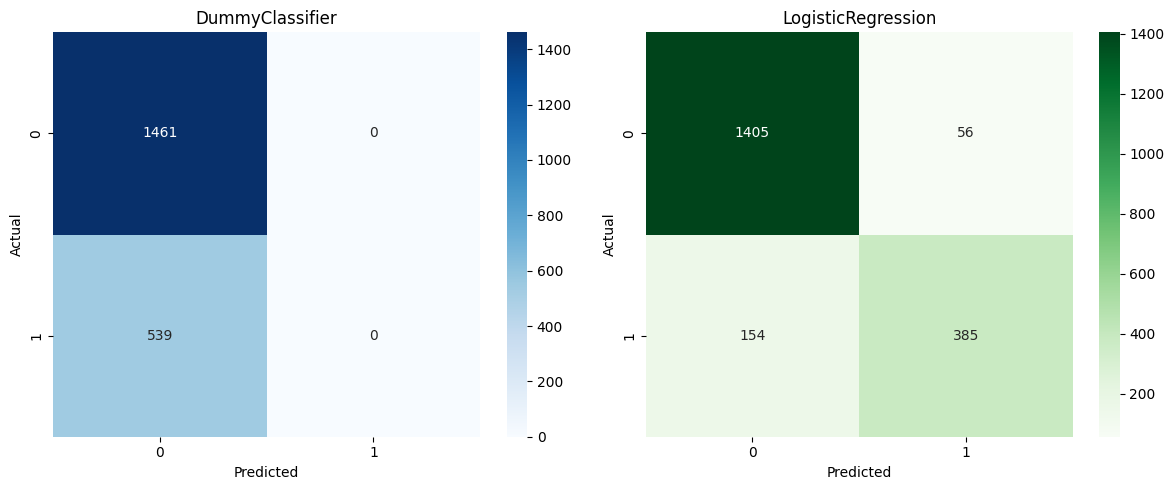

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dummy = confusion_matrix(y_test, y_pred_dummy)
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('DummyClassifier')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('LogisticRegression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 12. Анализ коэффициентов логистической регрессии

Так как используется логистическая регрессия, можно проанализировать коэффициенты признаков.  
Чем больше коэффициент по модулю, тем сильнее влияние признака на предсказание класса.


In [41]:
feature_names = logreg_model.named_steps['preprocessor'].get_feature_names_out()
coefs = logreg_model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

print('Топ-20 признаков по модулю коэффициента:')
display(coef_df.head(20))


Топ-20 признаков по модулю коэффициента:


,feature,coef,abs_coef
2,num__positive,16.766391,16.766391
3,num__negative,11.461685,11.461685
15877,cat__publisher_New Reality Games,1.699209,1.699209
12,num__ccu,1.597832,1.597832
13853,cat__publisher_Back To Basics Gaming,1.527622,1.527622
9526,cat__developer_Fabio Ferrara,1.379737,1.379737
9011,cat__developer_Cursed Studios,1.346582,1.346582
1429,cat__name_Cursed Dawn,1.346582,1.346582
14565,cat__publisher_Electronic Arts,1.278653,1.278653
11547,cat__developer_Pyro Studios,1.253565,1.253565


## 13. Вывод

В ходе работы был подготовлен датасет Steam Games и построена целевая переменная `ishit`, отражающая популярность игры по числу владельцев.

После предобработки данных были обучены:
- baseline-модель `DummyClassifier`;
- основная модель `LogisticRegression`.

Сравнение метрик позволяет сделать вывод о том, превосходит ли логистическая регрессия наивный baseline.  
Если значения `F1-score` и `ROC-AUC` у логистической регрессии выше, то модель действительно выявляет полезные закономерности в данных.

Таким образом, задача бинарной классификации была успешно решена, а логистическая регрессия может рассматриваться как базовая интерпретируемая модель для дальнейшего улучшения.
